In [1]:
import os
from datetime import datetime
from typing import List
import string
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from dateutil.rrule import MO
import matplotlib.cm as cm

In [2]:
tides_folder = r"D:\PhD\21_Experiments\TidesDamageDriver\01_raw\tides_CATS2008\v1"
figure_folder = r"D:\PhD\21_Experiments\TidesDamageDriver\figures"

In [3]:
walk = [w for w in os.walk(tides_folder) if len(w[1]) == 0]
files = [os.path.join(w[0], w[2][1]) for w in walk]

In [4]:
pd.read_csv(files[0], sep = " ", header=None, names=["date", "amplitude"], dtype={"date": str, "amplitude": float})

,date,amplitude
0,2018-12-01,0.581
1,2018-12-02,0.534
2,2018-12-03,0.850
3,2018-12-04,1.174
4,2018-12-05,1.439
...,...,...
86,2019-02-25,1.216
87,2019-02-26,1.096
88,2019-02-27,0.960
89,2019-02-28,0.831


In [79]:
tides = [pd.read_csv(f, sep = " ", header=None, names=["date", "amplitude"], dtype={"date": str, "amplitude": float}) for f in files]

tides_2018 = [t for t in tides if t["date"].iloc[:10].str.startswith("2018").any()]
tides_2019 = [t for t in tides if t["date"].iloc[:10].str.startswith("2019").any()][1:]
tides_2020 = [t for t in tides if t["date"].iloc[:10].str.startswith("2020").any()]

for tide in [tides_2018, tides_2019, tides_2020]:
    print(len(tide))
    for t in tide:
        t["date"] = pd.to_datetime(t["date"], format="%Y-%m-%d")

3
13
2


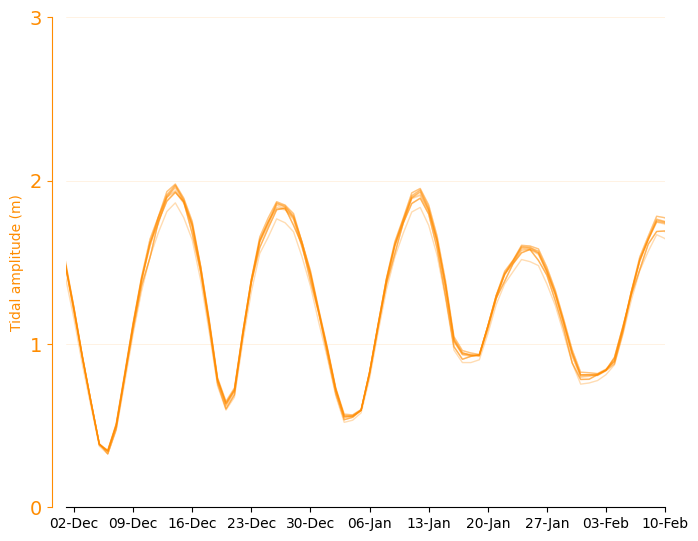

In [81]:
months = [11, 12, 1, 2]
color_tide = "darkorange"

color_tide2 = "red"
color_tide3 = "blue"

fig, ax = plt.subplots(figsize=(18 / 2.54, 14 / 2.54))
for i, tide in enumerate(tides_2019):
    dt = pd.to_datetime(tide["date"], format="%Y-%m-%d").copy()
    ax.plot(tide["date"], tide["amplitude"], color=color_tide, alpha=0.3, lw=1)

# for i, tide in enumerate(tides_2020):
#     dt = pd.to_datetime(tide["date"], format="%Y-%m-%d").copy() - pd.DateOffset(years=1)
#     print(dt.min(), dt.max())
#     ax.plot(dt, tide["amplitude"], color=color_tide2, alpha=0.3, lw=1)

# for i, tide in enumerate(tides_2018):
#     dt = pd.to_datetime(tide["date"], format="%Y-%m-%d") + pd.DateOffset(years=1)
#     ax.plot(dt, tide["amplitude"], color=color_tide3, alpha=0.3, lw=1)

ax.set_ylim(0, 3)
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(1))
ax.spines.left.set_position(("outward", 10))
ax.spines.left.set_color(color_tide)
ax.tick_params(axis="y", colors=color_tide)
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.grid(alpha = 0.2, color = color_tide, zorder = 0, axis = "y", lw = 0.4)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
ax.set_xlim([datetime(2019, 12, 1), datetime(2020, 2, 10)])
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=14)
ax.set_ylabel("Tidal amplitude (m)", color=color_tide)

fig.tight_layout()
fig.savefig(os.path.join(figure_folder, "figure_S4.pdf"), dpi=300)
fig.savefig(os.path.join(figure_folder, "figure_S4.png"), dpi=300)
plt.show()